In [1]:
import pandas as pd

hour_df = pd.read_parquet("/gpfs/gibbs/project/jain_snigdha/jl4286/eligibility/final_df_with_rass_criteria")

In [2]:
block_df = pd.read_parquet("/gpfs/gibbs/project/jain_snigdha/shared/EM_PTOT_project/ot_pt_statistical_analysis/all_hours_data/block_with_data_all_hours.parquet")

In [3]:
hour_df = hour_df[hour_df['encounter_block'].isin(block_df['encounter_block'])]
hour_df = hour_df.merge(block_df[['encounter_block', 'patient_id']], on='encounter_block', how='left')
print(hour_df["encounter_block"].nunique())
print(hour_df["patient_id"].nunique())
del block_df

32009
29296


In [4]:
def count_intubations(series):
    """Counts the number of re-intubations as 1->0->1 transitions."""
    return ((series.shift(1) == 1) & (series == 0) & (series.shift(-1) == 1)).sum() + (series.iloc[0] == 1)

intubation_count_df = (
    hour_df
    .sort_values(['encounter_block', 'recorded_date', 'recorded_hour'])  # Ensure proper chronological order
    .groupby('encounter_block')['hourly_on_vent']
    .apply(count_intubations)
    .reset_index()
    .rename(columns={'hourly_on_vent': 'intubation_count'})
)
intubation_count_df.head()

,encounter_block,intubation_count
0,97,1
1,104,1
2,118,1
3,141,1
4,143,1


In [5]:
hour_df = hour_df.merge(intubation_count_df, on='encounter_block', how='left')

## Summary Statistics of Intubation Count 

In [6]:
print(round(intubation_count_df['intubation_count'].describe(), 2))

count    32009.00
mean         1.00
std          0.07
min          1.00
25%          1.00
50%          1.00
75%          1.00
max          4.00
Name: intubation_count, dtype: float64


In [7]:
### num of encounter_block with > 1 intubations
(intubation_count_df['intubation_count'] > 1).sum()

np.int64(128)

In [8]:
### num of patients with > 1 intubations
intubation_count_df = intubation_count_df.merge(hour_df[['encounter_block', 'patient_id']].drop_duplicates(),
                                                on='encounter_block', how='left')
patient_intubation_sum = intubation_count_df.groupby('patient_id')['intubation_count'].sum()
(patient_intubation_sum > 1).sum()

np.int64(2250)

## Get PT in each intubation episode 

In [9]:
import numpy as np

hour_df['recorded_dttm'] = pd.to_datetime(hour_df['recorded_date']) + pd.to_timedelta(hour_df['recorded_hour'], unit='h')

def get_intubation_times(df):
    df = df.sort_values('recorded_dttm')
    on_vent = df['hourly_on_vent'].values

    # Find where intubation starts: 0→1 or start with 1
    prev = np.insert(on_vent[:-1], 0, 0)  # Shifted version with padding
    starts = (on_vent == 1) & (prev == 0)
    times = df.loc[starts, 'recorded_dttm'].values

    # Pad to 4 entries with NaT
    padded = list(times[:4]) + [pd.NaT] * (4 - len(times))
    return pd.Series(padded, index=[f'intubation{i}_dttm' for i in range(1, 5)])

intubation_times_df = (
    hour_df
    .groupby('encounter_block')
    .apply(get_intubation_times)
    .reset_index()
)

#hour_df = hour_df.merge(intubation_times_df, on='encounter_block', how='left')

/tmp/ipykernel_1160191/979340707.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(get_intubation_times)


In [10]:
pt_df = pd.read_csv("/gpfs/gibbs/project/jain_snigdha/shared/EM_PTOT_project/ot_pt_output/pt_consult.csv", parse_dates=["pt_time"])
pt_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29203 entries, 0 to 29202
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   subject_id    29203 non-null  int64         
 1   hadm_id       29203 non-null  int64         
 2   stay_id       29203 non-null  int64         
 3   caregiver_id  29203 non-null  float64       
 4   pt_time       29203 non-null  datetime64[ns]
 5   storetime     29203 non-null  object        
 6   itemid        29203 non-null  int64         
 7   value         29203 non-null  object        
 8   valuenum      0 non-null      float64       
 9   valueuom      0 non-null      float64       
 10  warning       29203 non-null  float64       
 11  patient_id    29203 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(5), object(2)
memory usage: 2.7+ MB


In [11]:
hour_df['patient_id'] = hour_df['patient_id'].astype(int)
hour_df['hospitalization_id'] = hour_df['hospitalization_id'].astype(int)
hour_df1 = hour_df[hour_df['patient_id'].isin(pt_df['patient_id'])]
hour_df1 = hour_df1[hour_df1['hospitalization_id'].isin(pt_df['hadm_id'])]
print(hour_df["patient_id"].nunique())
print(hour_df["hospitalization_id"].nunique())
print(hour_df1["patient_id"].nunique())
print(hour_df1["hospitalization_id"].nunique())

29296
32019
5627
5761


### get time_PT_intubation on original hour_df

In [12]:
intubation_times_df = intubation_times_df.merge(hour_df[['encounter_block', 'patient_id', 'hospitalization_id']].drop_duplicates(), on='encounter_block', how='left')

def get_first_pt_times(row):
    pid = row['patient_id']
    hadm = row['hospitalization_id']
    pt_times = pt_df.loc[
        (pt_df['patient_id'] == pid) & (pt_df['hadm_id'] == hadm),
        'pt_time'
    ].sort_values()

    result = {}
    for i in range(1, 5):
        dttm_col = f'intubation{i}_dttm'
        if pd.notna(row[dttm_col]):
            pt_after = pt_times[pt_times >= row[dttm_col]]
            result[f'time_PT_intubation{i}'] = pt_after.iloc[0] if not pt_after.empty else pd.NaT
        else:
            result[f'time_PT_intubation{i}'] = pd.NaT
    return pd.Series(result)

pt_times_result = intubation_times_df.apply(get_first_pt_times, axis=1)
temp_df = pd.concat([intubation_times_df, pt_times_result], axis=1)
temp_df.head()

,encounter_block,intubation1_dttm,intubation2_dttm,intubation3_dttm,intubation4_dttm,patient_id,hospitalization_id,time_PT_intubation1,time_PT_intubation2,time_PT_intubation3,time_PT_intubation4
0,97,2131-01-11 04:00:00,2131-01-13 04:00:00,NaT,NaT,10001884,26184834,2131-01-11 18:37:00,NaT,NaT,NaT
1,104,2160-05-18 14:00:00,NaT,NaT,NaT,10002013,23581541,NaT,NaT,NaT,NaT
2,118,2162-02-17 23:00:00,NaT,NaT,NaT,10002114,27793700,NaT,NaT,NaT,NaT
3,141,2156-04-19 20:00:00,NaT,NaT,NaT,10002428,28662225,NaT,NaT,NaT,NaT
4,143,2156-05-11 16:00:00,NaT,NaT,NaT,10002428,23473524,NaT,NaT,NaT,NaT


In [13]:
hour_df = hour_df.merge(
    temp_df[[
        'encounter_block',
        'intubation1_dttm', 'intubation2_dttm', 'intubation3_dttm', 'intubation4_dttm',
        'time_PT_intubation1', 'time_PT_intubation2', 'time_PT_intubation3', 'time_PT_intubation4'
    ]],
    on='encounter_block',
    how='left'
)

### get time_PT_intubation on filtered hour_df¶

In [14]:
intubation_times_df1 = (
    hour_df1
    .groupby('encounter_block')
    .apply(get_intubation_times)
    .reset_index()
)
intubation_times_df1 = intubation_times_df1.merge(hour_df1[['encounter_block', 'patient_id', 'hospitalization_id']].drop_duplicates(), on='encounter_block', how='left')
pt_times_result1 = intubation_times_df1.apply(get_first_pt_times, axis=1)
temp_df1 = pd.concat([intubation_times_df1, pt_times_result1], axis=1)
temp_df1.head()

/tmp/ipykernel_1160191/1186617542.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(get_intubation_times)


,encounter_block,intubation1_dttm,intubation2_dttm,intubation3_dttm,intubation4_dttm,patient_id,hospitalization_id,time_PT_intubation1,time_PT_intubation2,time_PT_intubation3,time_PT_intubation4
0,97,2131-01-11 04:00:00,2131-01-13 04:00:00,NaT,NaT,10001884,26184834,2131-01-11 18:37:00,NaT,NaT,NaT
1,167,2141-04-20 14:00:00,NaT,NaT,NaT,10002760,28094813,2141-04-20 17:50:00,NaT,NaT,NaT
2,288,2111-01-17 14:00:00,NaT,NaT,NaT,10004422,21255400,2111-01-17 17:50:00,NaT,NaT,NaT
3,306,2186-11-12 20:00:00,NaT,NaT,NaT,10004720,22081550,2186-11-12 23:49:00,NaT,NaT,NaT
4,331,2130-10-27 16:00:00,NaT,NaT,NaT,10005348,25239799,2130-10-27 22:24:00,NaT,NaT,NaT


In [15]:
hour_df1 = hour_df1.merge(
    temp_df1[[
        'encounter_block',
        'intubation1_dttm', 'intubation2_dttm', 'intubation3_dttm', 'intubation4_dttm',
        'time_PT_intubation1', 'time_PT_intubation2', 'time_PT_intubation3', 'time_PT_intubation4'
    ]],
    on='encounter_block',
    how='left'
)

In [19]:
### Count non-missing PT consults per intubation episode
pt_counts = {}

for i in range(1, 5):
    col = f'time_PT_intubation{i}'
    count = hour_df[hour_df[col].notna()]['encounter_block'].nunique()
    pt_counts[f'episode_{i}'] = count

# Display results
for episode, count in pt_counts.items():
    print(f"{episode}: {count} unique encounter_blocks with PT consult")

episode_1: 5194 unique encounter_blocks with PT consult
episode_2: 99 unique encounter_blocks with PT consult
episode_3: 4 unique encounter_blocks with PT consult
episode_4: 1 unique encounter_blocks with PT consult


## CIF Plots

In [22]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1819875 entries, 0 to 1819874
Data columns (total 100 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   encounter_block            int64         
 1   recorded_date              datetime64[ns]
 2   recorded_hour              int64         
 3   time_from_vent             int64         
 4   time_from_vent_adjusted    int64         
 5   min_fio2_set               float64       
 6   max_fio2_set               float64       
 7   min_peep_set               float64       
 8   max_peep_set               float64       
 9   min_lpm_set                float64       
 10  max_lpm_set                float64       
 11  min_resp_rate_obs          float64       
 12  max_resp_rate_obs          float64       
 13  hourly_trach               int64         
 14  hourly_on_vent             int64         
 15  avg_dbp                    float64       
 16  avg_heart_rate             float64 

In [40]:
hour_df['all_green_or_yellow'] = ((hour_df['all_green'] == 1) | (hour_df['yellow'] == 1)).astype(int)

hour_df['eligibile_now'] = hour_df['all_green_or_yellow']
hour_df['eligibile_1'] = hour_df.groupby('encounter_block')['all_green_or_yellow'].shift(1)
hour_df['eligibile_2'] = hour_df.groupby('encounter_block')['all_green_or_yellow'].shift(2)
hour_df['eligibile_3'] = hour_df.groupby('encounter_block')['all_green_or_yellow'].shift(3)

for col in ['eligibile_now', 'eligibile_1', 'eligibile_2', 'eligibile_3']:
    hour_df[col] = hour_df[col].fillna(0).astype(int)

In [41]:
hour_df['eligibility_dttm'] = pd.NaT
hour_df['eligibility_consec2_dttm'] = pd.NaT
hour_df['eligibility_consec4_dttm'] = pd.NaT

# Function to get eligibility dttm per encounter_block
def assign_consec_eligibility_times(group):
    # Get the boolean masks
    mask1 = (group['eligibile_now'] == 1) 
    mask2 = (group['eligibile_now'] == 1) & (group['eligibile_1'] == 1)
    mask4 = (
        (group['eligibile_now'] == 1) &
        (group['eligibile_1'] == 1) &
        (group['eligibile_2'] == 1) &
        (group['eligibile_3'] == 1)
    )

    # Assign recorded_dttm when condition met at eligibility_now = 1 row
    if mask1.any():
        idx1 = mask1.idxmax()  # first True
        group.loc[idx1, 'eligibility_dttm'] = group.loc[idx1, 'recorded_dttm']

    if mask2.any():
        idx2 = mask2.idxmax()  # first True
        group.loc[idx2, 'eligibility_consec2_dttm'] = group.loc[idx2, 'recorded_dttm']

    if mask4.any():
        idx4 = mask4.idxmax()
        group.loc[idx4, 'eligibility_consec4_dttm'] = group.loc[idx4, 'recorded_dttm']

    return group

# Apply function by encounter_block
hour_df = hour_df.groupby('encounter_block', group_keys=False).apply(assign_consec_eligibility_times)

/tmp/ipykernel_1160191/1329142100.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hour_df = hour_df.groupby('encounter_block', group_keys=False).apply(assign_consec_eligibility_times)


In [42]:
hour_df.head()

,encounter_block,recorded_date,recorded_hour,time_from_vent,time_from_vent_adjusted,min_fio2_set,max_fio2_set,min_peep_set,max_peep_set,min_lpm_set,...,all_green_or_yellow,eligibile_now,eligibile_1,eligibile_2,eligibile_3,eligibility_consec2_dttm,eligibility_consec4_dttm,time_eligibility_consec2,time_eligibility_consec4,eligibility_dttm
0,97,2131-01-11,4,0,-1,1.0,1.0,5.0,5.0,10.0,...,0,0,0,0,0,NaT,NaT,NaN,NaN,NaT
1,97,2131-01-11,5,1,-1,1.0,1.0,5.0,5.0,10.0,...,0,0,0,0,0,NaT,NaT,NaN,NaN,NaT
2,97,2131-01-11,6,2,-1,1.0,1.0,5.0,5.0,10.0,...,0,0,0,0,0,NaT,NaT,NaN,NaN,NaT
3,97,2131-01-11,7,3,-1,0.5,0.5,5.0,5.0,10.0,...,0,0,0,0,0,NaT,NaT,NaN,NaN,NaT
4,97,2131-01-11,8,4,0,0.5,0.5,5.0,5.0,10.0,...,1,1,0,0,0,NaT,NaT,NaN,NaN,2131-01-11 08:00:00


In [43]:
# Get first recorded_dttm per encounter_block
first_recorded = hour_df.groupby("encounter_block")["recorded_dttm"].transform("min")

# Calculate time difference
hour_df["time_eligibility"] = (hour_df["eligibility_dttm"] - first_recorded).dt.total_seconds() / 3600
hour_df["time_eligibility_consec2"] = (hour_df["eligibility_consec2_dttm"] - first_recorded).dt.total_seconds() / 3600
hour_df["time_eligibility_consec4"] = (hour_df["eligibility_consec4_dttm"] - first_recorded).dt.total_seconds() / 3600

In [50]:
hour_df["encounter_block"].nunique()

32009

In [44]:
hour_df["time_eligibility"].describe()

count    31357.000000
mean         4.555251
std          2.544260
min          2.000000
25%          4.000000
50%          4.000000
75%          4.000000
max         69.000000
Name: time_eligibility, dtype: float64

In [32]:
hour_df["time_eligibility_consec2"].describe()

count    31042.000000
mean         6.083242
std          3.718766
min          2.000000
25%          5.000000
50%          5.000000
75%          5.000000
max         72.000000
Name: time_eligibility_consec2, dtype: float64

In [35]:
hour_df["time_eligibility_consec4"].describe()

count    30504.000000
mean         9.507474
std          6.398016
min          2.000000
25%          7.000000
50%          7.000000
75%          9.000000
max         72.000000
Name: time_eligibility_consec4, dtype: float64

## CIF of Eligibility

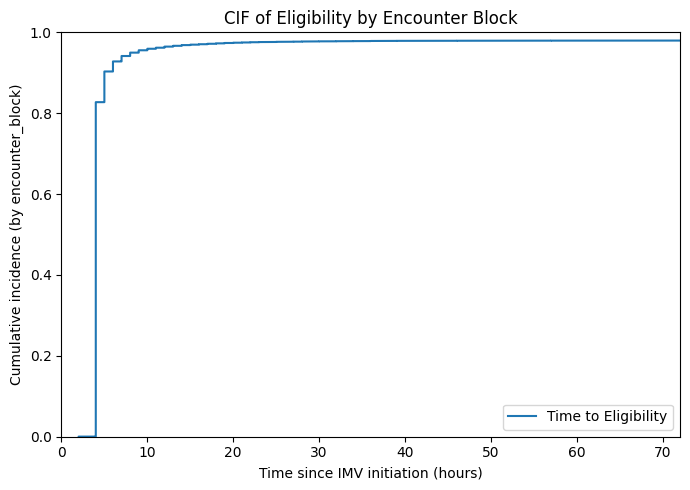

In [64]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

eligibility_df = (
    hour_df
    .groupby("encounter_block")["time_eligibility"]
    .apply(lambda x: x.dropna().min())   # first non-missing time
    .reset_index()
)

 # limit to 72h
df = eligibility_df.copy()
df["event"] = df["time_eligibility"].notna()
df["time"] = df["time_eligibility"].fillna(72)
df = df.sort_values("time")
times = df["time"].values
events = df["event"].astype(int).values
n = len(events)
cif = np.cumsum(events) / n

# plot
plt.figure(figsize=(7,5))
plt.step(times, cif, where='post', label="Time to Eligibility")
plt.xlim(0,72)
plt.ylim(0,1)

plt.xlabel("Time since IMV initiation (hours)")
plt.ylabel("Cumulative incidence (by encounter_block)")
plt.title("CIF of Eligibility by Encounter Block")
plt.legend()
plt.tight_layout()
plt.savefig("cif_eligibility.png", dpi=300, bbox_inches='tight')
plt.show()

## CIF of 2 consecutive hours Eligibility

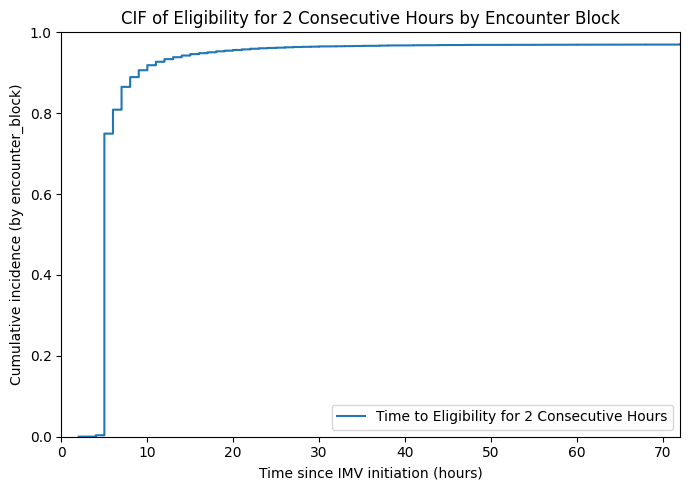

In [65]:
eligibility_df = (
    hour_df
    .groupby("encounter_block")["time_eligibility_consec2"]
    .apply(lambda x: x.dropna().min())   # first non-missing time
    .reset_index()
)

 # limit to 72h
df = eligibility_df.copy()
df["event"] = df["time_eligibility_consec2"].notna()
df["time"] = df["time_eligibility_consec2"].fillna(72)
df = df.sort_values("time")
times = df["time"].values
events = df["event"].astype(int).values
n = len(events)
cif = np.cumsum(events) / n

# plot
plt.figure(figsize=(7,5))
plt.step(times, cif, where='post', label="Time to Eligibility for 2 Consecutive Hours")
plt.xlim(0,72)
plt.ylim(0,1)

plt.xlabel("Time since IMV initiation (hours)")
plt.ylabel("Cumulative incidence (by encounter_block)")
plt.title("CIF of Eligibility for 2 Consecutive Hours by Encounter Block")
plt.legend()
plt.tight_layout()
plt.savefig("cif_eligibility2.png", dpi=300, bbox_inches='tight')
plt.show()

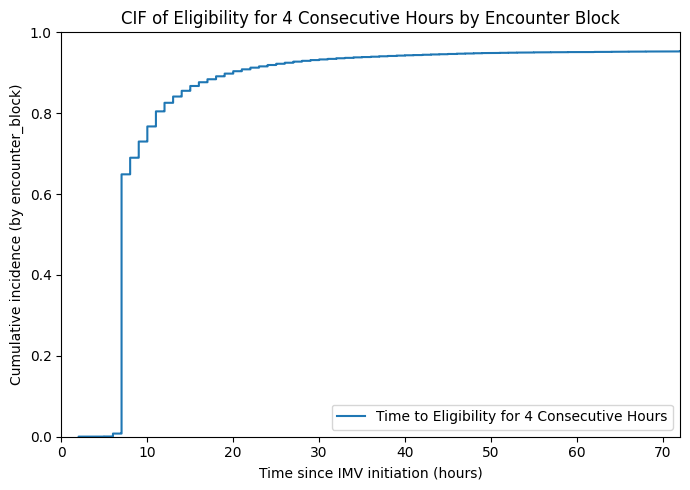

In [66]:
eligibility_df = (
    hour_df
    .groupby("encounter_block")["time_eligibility_consec4"]
    .apply(lambda x: x.dropna().min())   # first non-missing time
    .reset_index()
)

 # limit to 72h
df = eligibility_df.copy()
df["event"] = df["time_eligibility_consec4"].notna()
df["time"] = df["time_eligibility_consec4"].fillna(72)
df = df.sort_values("time")
times = df["time"].values
events = df["event"].astype(int).values
n = len(events)
cif = np.cumsum(events) / n

# plot
plt.figure(figsize=(7,5))
plt.step(times, cif, where='post', label="Time to Eligibility for 4 Consecutive Hours")
plt.xlim(0,72)
plt.ylim(0,1)

plt.xlabel("Time since IMV initiation (hours)")
plt.ylabel("Cumulative incidence (by encounter_block)")
plt.title("CIF of Eligibility for 4 Consecutive Hours by Encounter Block")
plt.legend()
plt.tight_layout()
plt.savefig("cif_eligibility4.png", dpi=300, bbox_inches='tight')
plt.show()

## CIF plot of Eligibility and PT

In [73]:
block_df = pd.read_parquet("/gpfs/gibbs/project/jain_snigdha/shared/EM_PTOT_project/ot_pt_statistical_analysis/block_with_data.parquet")
hour_df = hour_df.merge(
    block_df[['encounter_block', 'Time_first_PT_new']],
    on='encounter_block',
    how='left'
)

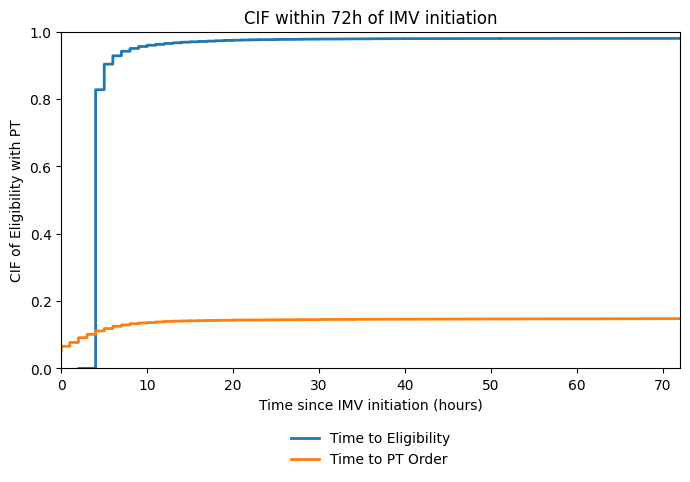

In [84]:
eligibility_df = (
    hour_df
    .groupby("encounter_block")["time_eligibility"]
    .apply(lambda x: x.dropna().min() if x.notna().any() else np.nan)
    .reset_index()
    .rename(columns={"time_eligibility": "eligibility_time"})
)
pt_df = (
    hour_df
    .groupby("encounter_block")["Time_first_PT_new"]
    .apply(lambda x: x.dropna().min() if x.notna().any() else np.nan)
    .reset_index()
    .rename(columns={"Time_first_PT_new": "pt_time"})
)
merged = eligibility_df.merge(pt_df, on="encounter_block", how="outer")

censor = 72
# Eligibility event indicator
merged["elig_event"] = ~merged["eligibility_time"].isna()
merged["elig_time"] = merged["eligibility_time"].fillna(censor)
# PT event indicator
merged["pt_event"] = ~merged["pt_time"].isna()
merged["pt_time_filled"] = merged["pt_time"].fillna(censor)

elig_sorted = np.sort(merged["elig_time"])
elig_events_sorted = merged.sort_values("elig_time")["elig_event"].values
pt_sorted = np.sort(merged["pt_time_filled"])
pt_events_sorted = merged.sort_values("pt_time_filled")["pt_event"].values
n = len(merged)
elig_cdf = np.cumsum(elig_events_sorted) / n
pt_cdf = np.cumsum(pt_events_sorted) / n

plt.figure(figsize=(7, 5))
plt.step(elig_sorted, elig_cdf, where='post', linewidth=2,
         label='Time to Eligibility')
plt.step(pt_sorted, pt_cdf, where='post', linewidth=2,
         label='Time to PT Order')
plt.xlim(0, 72)
plt.ylim(0, 1)
plt.xlabel("Time since IMV initiation (hours)")
plt.ylabel("CIF of Eligibility with PT")
plt.title("CIF within 72h of IMV initiation")
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=1,
    frameon=False
)
plt.tight_layout()
plt.savefig("cif_eligibility_pt.png", dpi=300, bbox_inches='tight')
plt.show()